In [ ]:
pip install -U finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.6 MB/s eta 0:00:00


In [ ]:
# mq_quant.py

import FinanceDataReader as fdr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

def get_close(ticker, start, end=None):
    """
    종가 데이터 수집 (Get Close Prices)
    """
    return fdr.DataReader(ticker, start, end)['Close']

def calc_daily_return(prices):
    """
    일별 수익률 계산 (Calculate Daily Returns)
    """
    return prices.pct_change().fillna(0)

def calc_cum_return(prices):
    """
    누적 수익률(자산 흐름) 계산 (Calculate Cumulative Returns)
    """
    return prices / prices.iloc[0]

def calc_portfolio(prices, weight=None):
    """
    포트폴리오 수익률 계산 (Calculate Portfolio Returns)
    returns: (일별 수익률, 누적 수익률)
    """
    # 1. 누적 수익률 계산
    cum_ret = calc_cum_return(prices)

    # 2. 비중 설정 (기본값: 동일 비중)
    if not weight:
        weight = [1/len(prices.columns)] * len(prices.columns)

    # 3. 포트폴리오 누적 수익률 (가중 평균)
    # 각 자산의 누적 수익률에 비중을 곱해 합산합니다. (Buy & Hold 가정)
    port_cum_ret = (cum_ret * weight).sum(axis=1)

    # 4. 포트폴리오 일별 수익률 (역산)
    port_daily_ret = port_cum_ret.pct_change().fillna(0)

    return port_daily_ret, port_cum_ret


def evaluate_performance(daily_ret, cum_ret, risk_free_rate=0.02):
    """
    성과 지표 평가 (CAGR, MDD, Volatility, Sharpe ratio)
    """

    # 1. 수익성 (CAGR)
    total_ret = cum_ret.iloc[-1]
    years = len(cum_ret) / 252
    cagr = total_ret ** (1 / years) - 1

    # 2. 안정성 (MDD)
    historical_max = cum_ret.cummax()
    dd = (cum_ret - historical_max) / historical_max * 100
    mdd = dd.min()

    # 3. 위험 (변동성)
    daily_vol = daily_ret.std()               # 일일 변동성
    annual_vol = daily_vol * np.sqrt(252)     # 연간 변동성

    # 4. 효율 (Sharpe Ratio)
    annual_return = daily_ret.mean() * 252    # 연간 수익률 (산술 평균)
    sharpe_ratio = (annual_return - risk_free_rate) / annual_vol # 위험 한 단위당 수익

    print(f"▶ 최종 수익률   : {(cum_ret.iloc[-1]-1)*100:.2f}%")
    print(f"=== 성과 평가 리포트 ===")
    print(f"1. 수익성 (CAGR) : {cagr*100:.2f}%")
    print(f"2. 안정성 (MDD)  : {mdd:.2f}%")
    print(f"-" * 30)
    print(f"3. 연간 변동성   : {annual_vol*100:.2f}%")
    print(f"4. 샤프 지수     : {sharpe_ratio:.4f}")

    return cagr, dd, mdd

def get_rebalancing_dates(close_data, period="month"):
    """
    리밸런싱 날짜 추출 (Pandas Grouper 활용)
    - 입력: 종가 데이터, 주기('month', 'quarter', 'year')
    - 출력: 리밸런싱 시행일(DatetimeIndex)
    """
    # 주기별 Pandas Frequency 문자열 매핑
    freq_map = {'month': 'ME', 'quarter': 'QE', 'year': 'YE'}

    # 1. 예외처리: 잘못된 주기 입력
    if period not in freq_map:
        raise ValueError("period must be 'month', 'quarter', or 'year'")

    freq = freq_map[period]

    rebalancing_dates = close_data.groupby(pd.Grouper(freq=freq)).apply(lambda x: x.index[-1])

    return rebalancing_dates.sort_index()


def cal_rebalancing_portfolio(close_data, period="month", weight_df=None, enable_plot=True):
    """
    리밸런싱 포트폴리오 성과 계산 (Chunk 방식)
    """

    # 1. 리밸런싱 날짜 구하기 (전체 데이터 기준)
    rebal_dates = get_rebalancing_dates(close_data, period)

    # 날짜 동기화 (weight_df가 있다면, 교집합 날짜만 사용)
    # close_data가 더 길어도, weight_df가 있는 기간만 백테스팅 수행
    if weight_df is not None:
        # weight_df 인덱스에 포함된 날짜만 필터링
        rebal_dates = rebal_dates[rebal_dates.isin(weight_df.index)]

        # 만약 겹치는 날짜가 하나도 없다면 에러 처리
        if rebal_dates.empty:
            print("Error: close_data와 weight_df의 리밸런싱 날짜가 일치하지 않습니다.")
            return None, None

    # 3. 초기 비중 설정 (없으면 동일 비중)
    if weight_df is None:
        n_assets = len(close_data.columns)
        weight_df = pd.DataFrame(
            index=rebal_dates,
            columns=close_data.columns,
            data=1/n_assets
        )

    # 4. 데이터 범위 보정 (시작일 기준)
    first_date = rebal_dates[0] # 필터링된 첫 날짜


    # 전체 기간 수익률 계산
    full_daily_rets = close_data.pct_change().fillna(0)

    # 백테스트 시작일 이후 데이터만 슬라이싱
    daily_rets = full_daily_rets.loc[first_date:]

    portfolio_chunks = []
    total_value = 1.0

    # 리밸런싱 기간별 순회
    full_dates = list(rebal_dates)

    # 마지막 구간 처리: 마지막 리밸런싱 날짜 ~ 데이터 끝 날짜
    # (단, daily_rets의 마지막 날짜가 리밸런싱 날짜보다 뒤에 있을 때만)
    if full_dates[-1] < daily_rets.index[-1]:
        full_dates.append(daily_rets.index[-1])

    for start, end in zip(full_dates[:-1], full_dates[1:]):

        # start가 weight_df에 없으면 건너뜀 (안전 장치)
        if start not in weight_df.index:
            continue

        current_weights = weight_df.loc[start]

        # start 다음날부터 end까지의 수익률 사용 (start 당일은 리밸런싱 날)
        chunk_rets = daily_rets.loc[start:end].iloc[1:]

        if chunk_rets.empty: continue

        cum_growth = (1 + chunk_rets).cumprod()
        chunk_value = (cum_growth * current_weights).sum(axis=1) * total_value
        portfolio_chunks.append(chunk_value)
        total_value = chunk_value.iloc[-1]

    # 6. 결과 병합
    if not portfolio_chunks:
        return None, None

    portfolio_cum_ret = pd.concat(portfolio_chunks)
    portfolio_cum_ret.loc[first_date] = 1.0 # 시작점 1.0 강제 할당
    portfolio_cum_ret = portfolio_cum_ret.sort_index()

    portfolio_day_ret = portfolio_cum_ret.pct_change().fillna(0)

    if enable_plot:
        historical_max = portfolio_cum_ret.cummax()
        dd = (portfolio_cum_ret - historical_max) / historical_max * 100
        mdd = dd.min()

        # [수정] 전체 컬럼이 아니라, weight_df에 존재하는(실제 투자된) 티커만 추출
        if weight_df is not None:
            # weight_df의 컬럼 중 close_data에도 존재하는 것만 리스트로 만듦 (KeyError 방지)
            tickers = [col for col in weight_df.columns if col in close_data.columns]

            if 'cash' in tickers: tickers.remove('cash')
        else:
            tickers = close_data.columns.tolist()

        plot_daily_rets = full_daily_rets.loc[portfolio_cum_ret.index]

        plot_portfolio_result(tickers, plot_daily_rets, portfolio_cum_ret, dd, mdd)

    return portfolio_day_ret, portfolio_cum_ret


def plot_portfolio_result(tickers, daily_rets, port_cum_ret, dd, mdd):
    """
    포트폴리오 성과 시각화 함수 (백테스트 기간 일치 버전)
    """

    plt.figure(figsize=(10, 8))

    # [차트 1] 포트폴리오 누적 수익률 (Asset Growth)
    plt.subplot(2, 1, 1)

    # 1. 메인 포트폴리오 선 그리기
    plt.plot(port_cum_ret.index, port_cum_ret, label='Portfolio', color='#d62728', linewidth=1.5)

    # 개별 종목 흐름 그리기 (기간 매칭 및 리베이스)
    if daily_rets is not None and tickers is not None:

        # 포트폴리오의 시작/종료 날짜 구하기
        start_date = port_cum_ret.index[0]
        end_date = port_cum_ret.index[-1]

        # 전체 데이터(daily_rets)를 실제 백테스트 기간만큼만 자르기
        subset_daily_rets = daily_rets.loc[start_date:end_date]

        for t in tickers:
            if t in subset_daily_rets.columns:
                # 잘라낸 기간의 수익률로 누적 수익률 새로 계산
                # 이렇게 해야 시작점이 1.0(혹은 포트폴리오 시작점) 근처로 맞춰집니다.
                ind_cum = (1 + subset_daily_rets[t]).cumprod()

                # 시각화 (투명도 조절)
                plt.plot(ind_cum.index, ind_cum, label=f'{t}', alpha=0.3, linewidth=0.8, linestyle='--')

    # Y축 로그 스케일 및 포맷 설정
    plt.yscale('log')
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mticker.ScalarFormatter())
    ax.ticklabel_format(style='plain', axis='y')

    plt.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
    plt.title('Portfolio Cumulative Return', fontsize=14, fontweight='bold')

    plt.legend(loc='upper left', fontsize='small')
    plt.grid(True, alpha=0.3)


    # [차트 2] 낙폭 (Drawdown)
    plt.subplot(2, 1, 2)

    plt.fill_between(dd.index, dd, 0, color='#1f77b4', alpha=0.3)
    plt.plot(dd.index, dd, color='#1f77b4', linewidth=0.5)

    plt.title('Portfolio Drawdown (MDD)', fontsize=12)
    plt.axhline(mdd, color='red', linestyle='--', label=f'Max DD: {mdd:.2f}%')

    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.ylabel('Drawdown (%)')

    plt.tight_layout()
    plt.show()


def cal_AvgMomentumScore(close_data, n=12, cutoff=None):
    """
    평균 모멘텀 스코어를 기반으로 한 투자 비중 구하기
    close_data: 종가 데이터
    n: 모멘텀 기간 1~n
    cutoff: 모멘텀 스코어 커트라인 (0~1). 이 값 미만인 종목은 투자 제외.
    return: 투자비중 weight df, 평균모멘텀 스코어 df
    """
    avgMomentumScore = 0 # 평모스 초기값
    priceOnRebalDate = close_data.loc[get_rebalancing_dates(close_data)] # 리밸런싱 일자의 가격 데이터

    # 1 ~ n개월 모멘텀 스코어 합
    for i in range(1, n+1):
        avgMomentumScore = np.where(priceOnRebalDate / priceOnRebalDate.shift(i) > 1, 1, 0) + avgMomentumScore

    # 평모스 계산
    avgMomentumScore = pd.DataFrame(avgMomentumScore, index=priceOnRebalDate.index, columns=priceOnRebalDate.columns) # dataframe 형변환
    avgMomentumScore = avgMomentumScore / n

    # [수정] Cutoff 적용
    if cutoff is not None:
        avgMomentumScore[avgMomentumScore < cutoff] = 0

    # 모멘텀 스코어에 따른 weight 계산
    # 스코어 합이 0일 수 있으므로(모두 탈락), divide 후 fillna(0)
    weight = avgMomentumScore.divide(avgMomentumScore.sum(axis=1), axis=0).fillna(0)

    # 투자 비중이 모두 0인 구간에서는 현금 보유
    weight['cash'] = np.where(weight.sum(axis=1) == 0, 1, 0)

    # 투자비중, 평모스 리턴
    return weight, avgMomentumScore

# 비중 결정 방법론(최소분산, 역변동성)

최소 분산 (Minimum Variance): 수익률 상관관계를 고려하여 포트폴리오 전체의 변동성을 가장 낮게 만드는 비중을 찾습니다.

역변동성 (Inverse Volatility, Naive Risk Parity): 변동성이 큰 종목은 비중을 줄이고, 변동성이 작은 종목은 비중을 늘려 개별 종목의 위험 기여도를 평준화합니다.

## 효율적 투자선

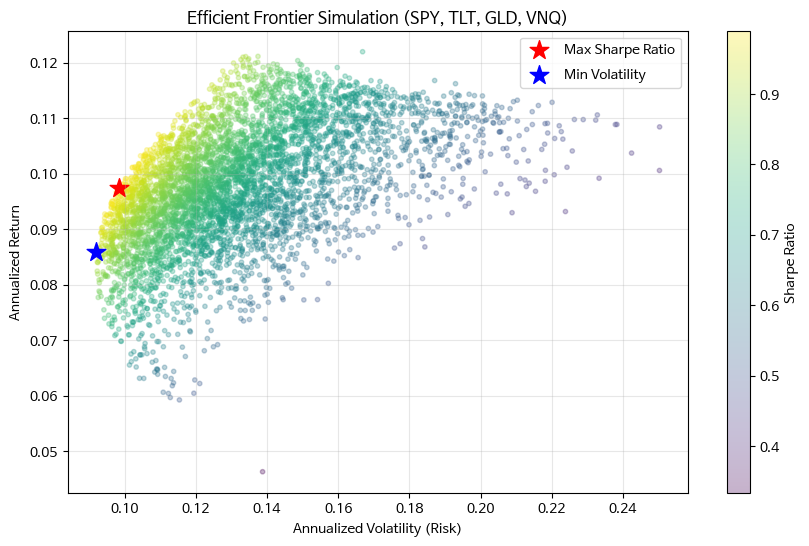

Max Sharpe Portfolio Weights:
SPY: 35.49%
TLT: 30.29%
GLD: 33.63%
VNQ: 0.58%

Min Volatility Portfolio Weights:
SPY: 31.03%
TLT: 44.73%
GLD: 23.29%
VNQ: 0.95%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('ETF 유니버스.csv', index_col=0)
df.index = pd.to_datetime(df.index)

# Select Assets for MPT Example
tickers = ['SPY', 'TLT', 'GLD', 'VNQ']
data = df[tickers].dropna()

# 2. Monte Carlo Simulation
num_portfolios = 5000
results = np.zeros((3, num_portfolios)) # 3 rows: Return, Volatility, Sharpe
weights_record = []

# Calculate Daily Returns
daily_rets = data.pct_change().fillna(0)
mean_daily_rets = daily_rets.mean()
cov_matrix = daily_rets.cov()

np.random.seed(42)

for i in range(num_portfolios):
    # Random Weights
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights) # Normalize to 1
    weights_record.append(weights)

    # Portfolio Return & Volatility (Annualized)
    portfolio_return = np.sum(mean_daily_rets * weights) * 252
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)

    # Store results
    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    results[2,i] = results[0,i] / results[1,i] # Sharpe Ratio (Risk-free = 0 for simplicity or relative comparison)

# 3. Find Optimal Portfolios
max_sharpe_idx = np.argmax(results[2])
min_vol_idx = np.argmin(results[1])

max_sharpe_ret = results[0, max_sharpe_idx]
max_sharpe_vol = results[1, max_sharpe_idx]

min_vol_ret = results[0, min_vol_idx]
min_vol_vol = results[1, min_vol_idx]

# 4. Plotting
plt.figure(figsize=(10, 6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', s=10, alpha=0.3)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Return')
plt.title('Efficient Frontier Simulation (SPY, TLT, GLD, VNQ)')

# Highlight Optimal Points
plt.scatter(max_sharpe_vol, max_sharpe_ret, marker='*', color='red', s=200, label='Max Sharpe Ratio')
plt.scatter(min_vol_vol, min_vol_ret, marker='*', color='blue', s=200, label='Min Volatility')

plt.legend(labelspacing=0.8)
plt.grid(True, alpha=0.3)
plt.show()

# Print Weights for optimal portfolios
print("Max Sharpe Portfolio Weights:")
for t, w in zip(tickers, weights_record[max_sharpe_idx]):
    print(f"{t}: {w:.2%}")

print("\nMin Volatility Portfolio Weights:")
for t, w in zip(tickers, weights_record[min_vol_idx]):
    print(f"{t}: {w:.2%}")

Simulating Period A (2013-01-01 ~ 2017-12-31)...
Simulating Period B (2018-01-01 ~ 2022-12-31)...


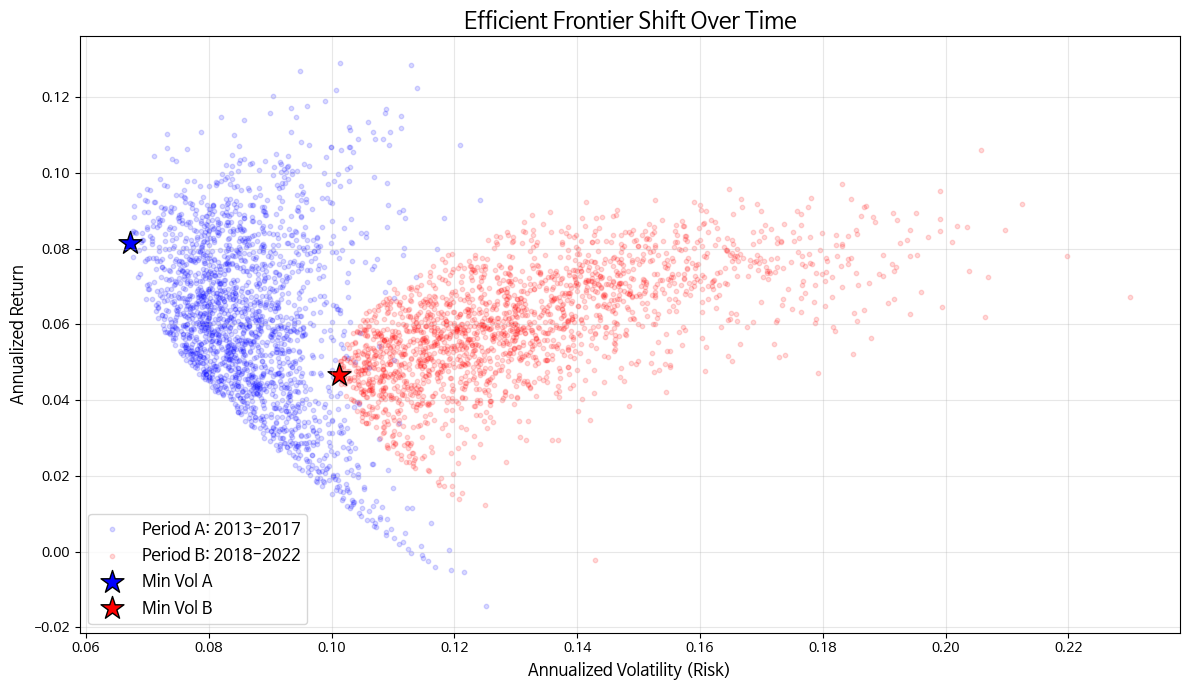


[Comparison]
Period A Min Vol: 6.71% (Return: 8.16%)
Period B Min Vol: 10.13% (Return: 4.66%)
-> Notice how the curve shifts and the optimal point moves.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('ETF 유니버스.csv', index_col=0)
df.index = pd.to_datetime(df.index)

# Select Assets
tickers = ['SPY', 'TLT', 'GLD', 'VNQ']
data = df[tickers].dropna()

# 2. Define Simulation Function
def simulate_efficient_frontier(data_subset, num_portfolios=2000):
    daily_rets = data_subset.pct_change().fillna(0)
    mean_daily_rets = daily_rets.mean()
    cov_matrix = daily_rets.cov()

    results = np.zeros((2, num_portfolios)) # 0: Return, 1: Volatility

    for i in range(num_portfolios):
        weights = np.random.random(len(tickers))
        weights /= np.sum(weights)

        portfolio_return = np.sum(mean_daily_rets * weights) * 252
        portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)

        results[0,i] = portfolio_return
        results[1,i] = portfolio_std_dev

    return results

# 3. Define Periods
# Period A: Bull Market / Stable (e.g., 2013-2017)
# Period B: Volatile / Crisis (e.g., 2018-2022)
period_a_start, period_a_end = '2013-01-01', '2017-12-31'
period_b_start, period_b_end = '2018-01-01', '2022-12-31'

data_a = data.loc[period_a_start:period_a_end]
data_b = data.loc[period_b_start:period_b_end]

# 4. Run Simulations
print(f"Simulating Period A ({period_a_start} ~ {period_a_end})...")
results_a = simulate_efficient_frontier(data_a)

print(f"Simulating Period B ({period_b_start} ~ {period_b_end})...")
results_b = simulate_efficient_frontier(data_b)

# 5. Plotting
plt.figure(figsize=(12, 7))

# Period A
plt.scatter(results_a[1,:], results_a[0,:], color='blue', alpha=0.15, s=10, label=f'Period A: {period_a_start[:4]}-{period_a_end[:4]}')
# Period B
plt.scatter(results_b[1,:], results_b[0,:], color='red', alpha=0.15, s=10, label=f'Period B: {period_b_start[:4]}-{period_b_end[:4]}')

# Highlight Min Volatility Points
min_vol_idx_a = np.argmin(results_a[1,:])
min_vol_idx_b = np.argmin(results_b[1,:])

plt.scatter(results_a[1, min_vol_idx_a], results_a[0, min_vol_idx_a], color='blue', marker='*', s=300, edgecolor='black', label='Min Vol A')
plt.scatter(results_b[1, min_vol_idx_b], results_b[0, min_vol_idx_b], color='red', marker='*', s=300, edgecolor='black', label='Min Vol B')

plt.title('Efficient Frontier Shift Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Comparison
print("\n[Comparison]")
print(f"Period A Min Vol: {results_a[1, min_vol_idx_a]*100:.2f}% (Return: {results_a[0, min_vol_idx_a]*100:.2f}%)")
print(f"Period B Min Vol: {results_b[1, min_vol_idx_b]*100:.2f}% (Return: {results_b[0, min_vol_idx_b]*100:.2f}%)")
print("-> Notice how the curve shifts and the optimal point moves.")

왜 이런 일이 벌어질까요?
효율적 투자선을 만드는 재료인 3가지 변수가 매일 바뀌기 때문입니다.

기대 수익률 (μ): 작년에 잘 나갔던 주식이 올해는 꼴찌가 될 수 있습니다.

변동성 (σ): 얌전하던 채권 시장이 금리 인상기에는 미친 듯이 날뜁니다.

상관관계 (ρ): 평소엔 반대로 움직이던 주식과 채권이, 위기 때는 같이 폭락(상관관계 급증)하기도 합니다.



실전 대응 전략

1)주기적 리밸런싱: "한 번 최적 비중은 영원한 최적 비중이다"라는 착각을 버리고, 최소 분기 또는 반기마다 최근 데이터를 반영해 효율적 투자선을 다시 그리고 비중을 조절합니다.

2)Lookback Period (관찰 기간) 조절: 너무 먼 과거(20년 전) 데이터는 현재 시장 상황을 반영하지 못할 수 있습니다. 보통 최근 1~3년(Short-term) 데이터와 장기 데이터를 적절히 섞어서 추정합니다.

3)최소분산(GMVP)의 재발견: 수익률 예측은 틀리기 쉽지만, "위험(변동성)"은 그나마 예측 가능성이 높습니다. 그래서 수익률 축(Y축)은 무시하고, 오직 위험 축(X축)만 보고 가장 왼쪽 점(최소분산 포트폴리오)을 쫓아가는 전략이 실전에서 더 강할 때가 많습니다.

# 최소분산 방법론

In [ ]:
# 랭킹 파일 로드
final_ranking = pd.read_csv('/content/저벨류성장_260104.csv')

# 2. 상위 20개 종목 추출
top_20 = final_ranking.head(20).copy()
top_20

,코드,통합순위,회사명,total_score,PER,PBR,매출액 25년3Q(E) YOY,영업이익 25년3Q(E) YOY,지배순이익 25년3Q(E) YOY
0,A088350,1,한화생명,91.360656,3.63,0.22,23.82,176.87,1053.22
1,A001450,2,현대해상,83.934426,2.60,0.53,18.37,139.37,196.69
2,A033530,3,SJG세종,83.540984,4.31,0.56,6.57,79.26,4792.53
3,A006730,4,서부T&D,82.704918,12.27,0.83,60.65,71.02,1329.28
4,A000880,5,한화,81.032787,4.89,0.56,45.57,155.83,31.55
5,A006650,6,대한유화,80.590164,16.61,0.49,33.27,249.83,247.18
6,A006910,7,보성파워텍,79.081967,12.73,2.51,190.87,1602.43,736.28
7,A078930,8,GS,78.262295,9.02,0.36,2.36,37.28,4530.33
8,A094820,9,일진파워,77.639344,19.61,1.38,74.12,1107.74,378.35
9,A031330,10,에스에이엠티,77.180328,7.88,0.89,40.13,84.63,88.67


In [ ]:
# 티커(종목코드) 전처리

def clean_ticker(ticker):
    ticker = str(ticker).replace('A', '') # 'A' 제거
    return ticker.zfill(6)                # 6자리로 채우기 (예: 5930 -> 005930)

tickers = top_20['코드'].apply(clean_ticker).tolist()
names = top_20['회사명'].tolist()

print(f"상위 20개 종목의 주가 데이터를 수집합니다... ({len(tickers)}개)")
print(f"대상 종목: {names}")

상위 20개 종목의 주가 데이터를 수집합니다... (20개)
대상 종목: ['한화생명', '현대해상', 'SJG세종', '서부T&D', '한화', '대한유화', '보성파워텍', 'GS', '일진파워', '에스에이엠티', 'DL이앤씨', 'KCC', '한국전력', 'SK스퀘어', '우진', '한국금융지주', 'HD현대인프라코어', '바이오스마트', 'NH투자증권', '에스엠']


In [ ]:
import time

# 주가 데이터 수집 (통합 데이터 저장용)

all_data = [] # 원본 데이터 저장용 리스트 (Long Format)
price_data = {} # 최적화 계산용 딕셔너리 (Key: 종목명, Value: Series)

start_date = '2024-01-01'

for code, name in zip(tickers, names):
    try:
        print(f"수집 중: {name} ({code}) ...")

        # 데이터 수집
        df = fdr.DataReader(code, start_date)

        # 저장용 데이터 처리 (Long Format)
        df_save = df.copy()
        df_save['종목명'] = name
        df_save['코드'] = code
        df_save = df_save.reset_index()
        all_data.append(df_save)

        # 최적화용 데이터 처리 (Close Price)
        price_data[name] = df['Close']

        # 서버 부하 방지
        time.sleep(0.1)

    except Exception as e:
        print(f"에러 발생 ({name}): {e}")

# 수집된 데이터가 없으면 종료
if not all_data:
    print("수집된 데이터가 없습니다. 프로그램을 종료합니다.")
    exit()

수집 중: 한화생명 (088350) ...
수집 중: 현대해상 (001450) ...
수집 중: SJG세종 (033530) ...
수집 중: 서부T&D (006730) ...
수집 중: 한화 (000880) ...
수집 중: 대한유화 (006650) ...
수집 중: 보성파워텍 (006910) ...
수집 중: GS (078930) ...
수집 중: 일진파워 (094820) ...
수집 중: 에스에이엠티 (031330) ...
수집 중: DL이앤씨 (375500) ...
수집 중: KCC (002380) ...
수집 중: 한국전력 (015760) ...
수집 중: SK스퀘어 (402340) ...
수집 중: 우진 (105840) ...
수집 중: 한국금융지주 (071050) ...
수집 중: HD현대인프라코어 (042670) ...
수집 중: 바이오스마트 (038460) ...
수집 중: NH투자증권 (005940) ...
수집 중: 에스엠 (041510) ...


In [ ]:
# 통합 주가 데이터 저장
final_df = pd.concat(all_data)

# 최적화용 데이터프레임 생성 (Wide Format: 날짜 x 종목)
price_df = pd.DataFrame(price_data)

# 결측치 제거 (상장일이 다르거나 거래정지 등으로 데이터가 빈 경우 처리)
price_df = price_df.dropna()
print(f"최적화 분석에 사용될 데이터 기간: {price_df.index.min()} ~ {price_df.index.max()}")

최적화 분석에 사용될 데이터 기간: 2024-01-02 00:00:00 ~ 2026-01-15 00:00:00


In [ ]:
# 포트폴리오 최적화 엔진

# 일간 수익률 및 공분산 행렬 계산
daily_ret = price_df.pct_change().dropna()
cov_matrix = daily_ret.cov() * 252 # 연율화



## 최소 분산 함수

In [ ]:
from scipy.optimize import minimize

def get_min_var_weights(cov_mat):
    n = len(cov_mat)
    args = (cov_mat,)

    # 목적함수: 포트폴리오 변동성(분산) 최소화
    def portfolio_variance(weights, cov_mat):
        return weights.T @ cov_mat @ weights

    # 제약조건: 비중의 합은 1
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    # 범위: 0~1 (매수 전용) 숫자를 조절하며 상한선을 둘 수 있음
    bounds = tuple((0.0, 1) for asset in range(n))
    # 초기값
    init_guess = [1./n] * n

    result = minimize(portfolio_variance, init_guess, args=args,
                      method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

In [ ]:
#  기대 수익률이 최소 연 5%는 넘어야 한다는 제약조건(constraints)을 추가도 가능

# from scipy.optimize import minimize
# import numpy as np

# def get_min_var_portfolio(cov_mat, exp_rets, target_return=0.05):
#     """
#     target_return: 목표 연수익률 (예: 0.05 = 5%)
#     exp_rets: 각 자산별 기대 수익률 벡터 (일별 평균 수익률 등)
#     """
#     n = len(cov_mat)

#     # 1. 목적 함수: 변동성 최소화
#     def portfolio_variance(weights):
#         return weights.T @ cov_mat @ weights

#     # 2. 제약조건 설정
#     constraints = [
#         # 비중의 합은 1 (Equality)
#         {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},

#         # 기대 수익률 >= 목표 수익률 (Inequality)
#         {'type': 'ineq', 'fun': lambda x: np.sum(x * exp_rets) * 252 - target_return}
#     ]

#     # 3. 범위 설정 (0 ~ 100%)
#     bounds = tuple((0.0, 1.0) for _ in range(n))
#     init_guess = [1./n] * n

#     # 4. 최적화 실행
#     result = minimize(portfolio_variance, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

#     return result.x

# # --- 사용 예시 ---
# # mean_daily_rets: 자산별 일평균 수익률 (사전에 계산 필요)
# optimal_weights = get_min_var_portfolio(cov_matrix, mean_daily_rets, target_return=0.07)

# 역변동성 방법론

In [ ]:
def get_inv_vol_weights(daily_ret):
    # 연 변동성
    volatility = daily_ret.std() * np.sqrt(252)
    # 변동성의 역수
    inv_vol = 1 / volatility
    # 비중 정규화
    weights = inv_vol / inv_vol.sum()
    return weights.values

In [ ]:
# 비중 계산 및 결과 정리
# 최적화 수행
w_min_var = get_min_var_weights(cov_matrix)
w_inv_vol = get_inv_vol_weights(daily_ret)
w_equal = np.array([1/len(price_df.columns)] * len(price_df.columns))

# 결과 데이터프레임 생성
# 주의: dropna로 인해 일부 종목이 탈락했을 수 있으므로 price_df.columns 기준 매칭
portfolio = pd.DataFrame({
    '종목명': price_df.columns,
    '동일비중': w_equal,
    '역변동성_비중': w_inv_vol,
    '최소분산_비중': w_min_var
})


In [ ]:
# 원본 랭킹 점수 병합 (종목명 기준)
portfolio = pd.merge(portfolio, top_20[['회사명', 'total_score']], left_on='종목명', right_on='회사명', how='left')
portfolio = portfolio.drop(columns=['회사명']) # 중복 컬럼 제거

# 보기 좋게 포맷팅 (%)
portfolio['동일비중(%)'] = portfolio['동일비중'].apply(lambda x: f"{x*100:.1f}%")
portfolio['역변동성(%)'] = portfolio['역변동성_비중'].apply(lambda x: f"{x*100:.1f}%")
portfolio['최소분산(%)'] = portfolio['최소분산_비중'].apply(lambda x: f"{x*100:.1f}%")

# 점수가 높은 순으로 정렬하여 출력
portfolio = portfolio.sort_values('total_score', ascending=False)

In [ ]:
from tabulate import tabulate
print_cols = ['종목명', 'total_score', '동일비중(%)', '역변동성(%)', '최소분산(%)']
print_df = portfolio[print_cols]

print(tabulate(print_df, headers='keys', tablefmt='psql', floatfmt=".2f"))


+----+------------------+---------------+---------------+---------------+---------------+
|    | 종목명           |   total_score | 동일비중(%)   | 역변동성(%)   | 최소분산(%)   |
|----+------------------+---------------+---------------+---------------+---------------|
|  0 | 한화생명         |         91.36 | 5.0%          | 5.9%          | 2.1%          |
|  1 | 현대해상         |         83.93 | 5.0%          | 6.5%          | 11.6%         |
|  2 | SJG세종          |         83.54 | 5.0%          | 4.6%          | 2.7%          |
|  3 | 서부T&D          |         82.70 | 5.0%          | 5.2%          | 9.9%          |
|  4 | 한화             |         81.03 | 5.0%          | 3.8%          | 0.0%          |
|  5 | 대한유화         |         80.59 | 5.0%          | 4.1%          | 0.0%          |
|  6 | 보성파워텍       |         79.08 | 5.0%          | 3.9%          | 0.0%          |
|  7 | GS               |         78.26 | 5.0%          | 6.0%          | 8.2%          |
|  8 | 일진파워         |         77.64 | 5.0%      

# 팩터가중(평균모멘텀 스코어)

In [ ]:
# 랭킹 파일 로드
final_ranking = pd.read_csv('/content/저벨류성장_260104.csv')

# 2. 상위 20개 종목 추출
top_20 = final_ranking.head(20).copy()
top_20

def clean_ticker(ticker):
    ticker = str(ticker).replace('A', '').strip()
    return ticker.zfill(6)

tickers = top_20['코드'].apply(clean_ticker).tolist()
names = top_20['회사명'].tolist()

print(f"상위 20개 종목의 주가 데이터를 수집합니다... ({len(tickers)}개)")

상위 20개 종목의 주가 데이터를 수집합니다... (20개)


In [ ]:
# 주가 데이터 수집 (최근 13개월 이상)
# 12개월 모멘텀을 구하려면 최소 13개월치 데이터가 필요합니다.
start_date = '2023-01-01'
price_data = {}

for code, name in zip(tickers, names):
    try:
        df = fdr.DataReader(code, start_date)
        price_data[name] = df['Close']
        time.sleep(0.1)
    except Exception as e:
        print(f"에러 발생 ({name}): {e}")

price_df = pd.DataFrame(price_data).dropna()

In [ ]:
# 함수 실행 (Cutoff 0.25 적용 -> 12개월 중 3번 미만 상승 시 탈락)
cutoff_value = 0.25
weights_history, scores_history = cal_AvgMomentumScore(price_df, n=12, cutoff=cutoff_value)

In [ ]:
# 최종 결과 정리 및 출력

# 가장 최근 리밸런싱 시점의 비중 가져오기
latest_date = weights_history.index[-1]
latest_weights = weights_history.iloc[-1]
latest_scores = scores_history.iloc[-1]


# 현금 비중 분리
if 'cash' in latest_weights.index:
    cash_weight = latest_weights['cash']
    latest_weights = latest_weights.drop('cash')
    latest_scores = latest_scores.drop('cash', errors='ignore')
else:
    cash_weight = 0.0

portfolio = pd.DataFrame({
    '종목명': latest_weights.index,
    '팩터가중': latest_weights.values,
    '모멘텀스코어': latest_scores.values
})

portfolio

,종목명,팩터가중,모멘텀스코어
0,한화생명,0.043689,0.750000
1,현대해상,0.029126,0.500000
2,SJG세종,0.058252,1.000000
3,서부T&D,0.058252,1.000000
4,한화,0.058252,1.000000
5,대한유화,0.058252,1.000000
6,보성파워텍,0.053398,0.916667
7,GS,0.058252,1.000000
8,일진파워,0.058252,1.000000
9,에스에이엠티,0.053398,0.916667


In [ ]:

w_inv_vol = get_inv_vol_weights(daily_ret)

In [ ]:
invvol_weight_df   =get_inv_vol_weights(daily_ret) # 역변동성 비중 (index: 리밸 = 런싱 날짜, columns: 종목)
minvar_weight_df   =get_min_var_weights(cov_matrix) # 최소분산 비중
factor_weight_df   =weights_history


In [ ]:
# 한글 폰트 설치 및 설정 (런타임 재시작 없이 적용 시도)
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 1. 폰트 설치 (Nanum Fonts)
# -qq: quiet mode (출력 최소화)
!apt-get -qq -y install fonts-nanum > /dev/null

# 2. 폰트 경로 지정 및 등록
fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

# 파일이 설치되었는지 확인 후 설정
if os.path.exists(fontpath):
    fm.fontManager.addfont(fontpath)

    # 3. 폰트 설정 적용
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
    print("한글 폰트가 설치되고 설정되었습니다. 이제 그래프를 다시 그려보세요.")
else:
    print("폰트 설치에 실패했습니다. 코드를 다시 실행해 보거나 런타임을 재시작해야 할 수 있습니다.")

한글 폰트가 설치되고 설정되었습니다. 이제 그래프를 다시 그려보세요.


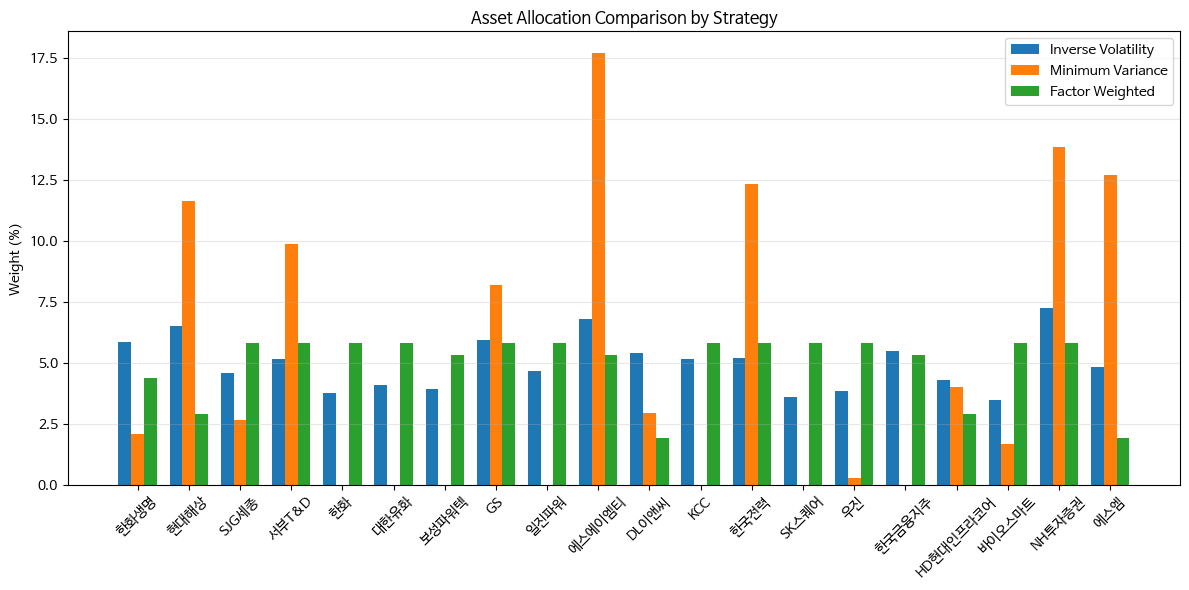

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 역변동성, 최소분산은 전체 기간 계산 결과(Array)이므로 Series로 변환 (인덱스 매핑)
invvol_w = pd.Series(invvol_weight_df, index=daily_ret.columns)
minvar_w = pd.Series(minvar_weight_df, index=daily_ret.columns)

# 팩터가중은 시계열(DataFrame)이므로 마지막 시점 추출
factor_w = factor_weight_df.iloc[-1]

# 공통 종목만 사용 (cash 등 자동 정리)
# 팩터 가중 전략에만 있는 'cash' 등은 교집합 연산에서 제외됨
assets = invvol_w.index.intersection(minvar_w.index).intersection(factor_w.index)

invvol_w = invvol_w[assets]
minvar_w = minvar_w[assets]
factor_w = factor_w[assets]

# ===============================
# 2️⃣ 하나의 DataFrame으로 병합
# ===============================
weight_compare = pd.DataFrame({
    'Inverse Volatility': invvol_w,
    'Minimum Variance'  : minvar_w,
    'Factor Weighted'   : factor_w
})

# ===============================
# 3️⃣ 막대그래프 (Grouped Bar Chart)
# ===============================
x = np.arange(len(weight_compare.index))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, weight_compare['Inverse Volatility'] * 100, width, label='Inverse Volatility')
plt.bar(x,          weight_compare['Minimum Variance'] * 100, width, label='Minimum Variance')
plt.bar(x + width,  weight_compare['Factor Weighted'] * 100, width, label='Factor Weighted')

plt.xticks(x, weight_compare.index, rotation=45)
plt.ylabel('Weight (%)')
plt.title('Asset Allocation Comparison by Strategy')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()